# App-10 : Optimisation de portefeuille par algorithme génétique

**Navigation** : [<< App-9 EdgeDetection](../Hybrid/App-9-EdgeDetection.ipynb) | [Index](../README.md) | [App-11 Picross >>](../CSP/App-11-Picross.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Modeliser** un portefeuille financier (rendement, risque, ratio de Sharpe)
2. **Appliquer** la scalarisation (PyGAD) puis NSGA-II (pymoo) a l'optimisation bi-objectif
3. **Construire** la frontiere efficiente de Markowitz par exploration parametrique
4. **Comparer** echantillonnage aleatoire, GA mono-objectif, scalarisation, NSGA-II et solveur exact

### Prerequis
- Python 3.10+ (numpy, matplotlib)
- Search-5 : Algorithmes génétiques (concepts de fitness, sélection, crossover, mutation)

### Duree estimee : 40 minutes

> **Side track** : Voir [App-10b C#](App-10b-Portfolio-CSharp.ipynb) pour la version GeneticSharp de ce problème.

## 1. Introduction

### La théorie moderne du portefeuille

En 1952, Harry **Markowitz** revolutionne la finance en formalisant le problème de l'allocation d'actifs comme un problème d'**optimisation bi-objectif** :

| Objectif | Description | Mesure |
|----------|-------------|--------|
| **Maximiser le rendement** | Rendement attendu du portefeuille | $R_p = \mathbf{w}^T \boldsymbol{\mu}$ |
| **Minimiser le risque** | Volatilite du portefeuille | $\sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}$ |

Ces deux objectifs sont **contradictoires** : les actifs a haut rendement sont généralement plus risques. La **frontiere efficiente** (ou frontiere de Pareto) represente l'ensemble des portefeuilles optimaux pour lesquels on ne peut ameliorer un objectif sans degrader l'autre.

### Pourquoi un algorithme génétique ?

Les méthodes classiques (programmation quadratique) resolvent ce problème efficacement dans le cas standard. Cependant, les algorithmes génétiques offrent des avantages dans les cas plus complexes :

| Situation | Avantage du GA |
|-----------|----------------|
| Contraintes non-lineaires | Gestion naturelle par penalite ou reparation |
| Espace discret | Les poids peuvent etre restreints a des multiples |
| Multi-objectif | NSGA-II produit directement la frontiere de Pareto |
| Fonction objectif bruitee | Robustesse aux evaluations stochastiques |

Dans ce notebook, nous utiliserons **PyGAD** pour optimiser un portefeuille de 5 actifs et reconstruire la frontiere efficiente.

In [1]:
# Imports et configuration
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import time

# Ajouter le repertoire Search/ (contenant search_helpers.py) :
# App-10 vit dans Search/Applications/Hybrid/, il faut remonter de 2 niveaux.
sys.path.insert(0, os.path.abspath("../.."))

# Mode batch pour execution non-interactive (Papermill/MCP)
BATCH_MODE = os.getenv("BATCH_MODE", "false").lower() in ("true", "1", "yes")
if BATCH_MODE:
    plt.ioff()

# Reproductibilite
np.random.seed(42)

# Import search_helpers pour benchmark_table
try:
    from search_helpers import benchmark_table
    HAS_HELPERS = True
except ImportError:
    HAS_HELPERS = False
    print("search_helpers non disponible, utilisation d'un affichage simplifie.")

# Import PyGAD
try:
    import pygad
    HAS_PYGAD = True
    print(f"PyGAD version {pygad.__version__} disponible.")
except ImportError:
    HAS_PYGAD = False
    print("PyGAD non disponible. Installer avec : pip install pygad")

print("Environnement pret.")

PyGAD version 3.5.0 disponible.
Environnement pret.


## 2. Modèle de portefeuille

### Definition des actifs

Nous considerons 5 actifs financiers avec des rendements attendus croissants et une matrice de covariance realiste. Les correlations positives entre actifs refletent le comportement typique des marches financiers.

### Notations mathematiques

| Symbole | Description |
|---------|-------------|
| $\mathbf{w} = (w_1, \ldots, w_5)$ | Vecteur des poids (allocation) |
| $\boldsymbol{\mu} = (\mu_1, \ldots, \mu_5)$ | Vecteur des rendements attendus |
| $\Sigma$ | Matrice de covariance $5 \times 5$ |
| $R_p = \mathbf{w}^T \boldsymbol{\mu}$ | Rendement du portefeuille |
| $\sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}$ | Risque (ecart-type) du portefeuille |
| $S = \frac{R_p - R_f}{\sigma_p}$ | Ratio de Sharpe ($R_f$ = taux sans risque) |

**Contraintes** : $w_i \geq 0$ (pas de vente a decouvert) et $\sum_{i=1}^{5} w_i = 1$ (allocation totale).

In [2]:
# --- Definition du modele de portefeuille ---

# Noms des actifs
asset_names = ["Obligations", "Immobilier", "Actions EU", "Actions US", "Emergents"]

# Rendements attendus annuels
expected_returns = np.array([0.05, 0.10, 0.15, 0.20, 0.25])

# Matrice de covariance (5x5) - correlations realistes
# Diagonale : variance de chaque actif (risque^2)
# Hors-diagonale : covariances (correlations positives moderees)
cov_matrix = np.array([
    [0.0100, 0.0012, 0.0018, 0.0021, 0.0025],
    [0.0012, 0.0200, 0.0022, 0.0026, 0.0028],
    [0.0018, 0.0022, 0.0300, 0.0031, 0.0033],
    [0.0021, 0.0026, 0.0031, 0.0400, 0.0043],
    [0.0025, 0.0028, 0.0033, 0.0043, 0.0500],
])

# Taux sans risque (pour le ratio de Sharpe)
risk_free_rate = 0.02

n_assets = len(asset_names)

# Afficher les caracteristiques de chaque actif
print("Caracteristiques des actifs")
print("=" * 55)
print(f"{'Actif':<15} {'Rendement':<12} {'Risque (std)':<12} {'Sharpe ind.':<12}")
print("-" * 55)
for i in range(n_assets):
    risk_i = np.sqrt(cov_matrix[i, i])
    sharpe_i = (expected_returns[i] - risk_free_rate) / risk_i
    print(f"{asset_names[i]:<15} {expected_returns[i]:>8.1%}    {risk_i:>8.1%}    {sharpe_i:>8.2f}")
print("=" * 55)

Caracteristiques des actifs
Actif           Rendement    Risque (std) Sharpe ind. 
-------------------------------------------------------
Obligations         5.0%       10.0%        0.30
Immobilier         10.0%       14.1%        0.57
Actions EU         15.0%       17.3%        0.75
Actions US         20.0%       20.0%        0.90
Emergents          25.0%       22.4%        1.03


### Interpretation : Caractéristiques individuelles des actifs

| Actif | Rendement | Risque | Observation |
|-------|-----------|--------|-------------|
| Obligations | 5% | ~10% | Faible rendement, faible risque (actif defensif) |
| Immobilier | 10% | ~14% | Rendement modere, risque modere |
| Actions EU | 15% | ~17% | Profil equilibre |
| Actions US | 20% | ~20% | Rendement eleve, risque eleve |
| Emergents | 25% | ~22% | Rendement maximal, risque maximal |

**Point cle** : Le ratio de Sharpe individuel permet de comparer les actifs sur une base ajustee du risque. Un actif avec un Sharpe eleve offre un meilleur rendement par unite de risque. Cependant, la diversification peut faire mieux que le meilleur actif individuel grace a la **reduction du risque par decorrelation**.

### Fonctions utilitaires du portefeuille

Definissons les fonctions de calcul du rendement, du risque et du ratio de Sharpe pour un vecteur de poids donne.

In [3]:
def portfolio_return(weights: np.ndarray) -> float:
    """Rendement attendu du portefeuille : R_p = w^T * mu."""
    return weights @ expected_returns


def portfolio_risk(weights: np.ndarray) -> float:
    """Risque (ecart-type) du portefeuille : sigma_p = sqrt(w^T * Sigma * w)."""
    variance = weights @ cov_matrix @ weights
    return np.sqrt(variance)


def sharpe_ratio(weights: np.ndarray, rf: float = risk_free_rate) -> float:
    """Ratio de Sharpe : S = (R_p - R_f) / sigma_p."""
    ret = portfolio_return(weights)
    risk = portfolio_risk(weights)
    if risk < 1e-10:
        return 0.0
    return (ret - rf) / risk


def normalize_weights(weights: np.ndarray) -> np.ndarray:
    """Normalise les poids pour que leur somme soit 1 (et tous >= 0)."""
    w = np.maximum(weights, 0)  # Pas de poids negatifs
    total = w.sum()
    if total < 1e-10:
        return np.ones(n_assets) / n_assets  # Equiponderation par defaut
    return w / total


# Verification avec un portefeuille equipondere
w_equal = np.ones(n_assets) / n_assets
print(f"Portefeuille equipondere : {w_equal}")
print(f"  Rendement : {portfolio_return(w_equal):.2%}")
print(f"  Risque    : {portfolio_risk(w_equal):.2%}")
print(f"  Sharpe    : {sharpe_ratio(w_equal):.4f}")

Portefeuille equipondere : [0.2 0.2 0.2 0.2 0.2]
  Rendement : 15.00%
  Risque    : 8.98%
  Sharpe    : 1.4469


### Visualisation des actifs individuels

Placons chaque actif sur un graphe risque-rendement pour visualiser le compromis fondamental.

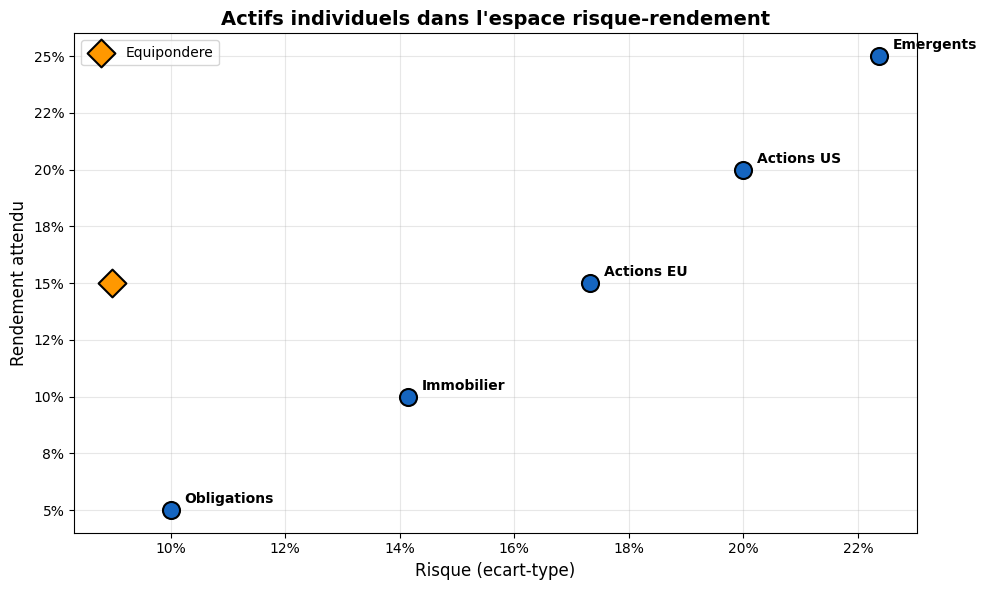

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# Tracer chaque actif individuel
individual_risks = [np.sqrt(cov_matrix[i, i]) for i in range(n_assets)]
individual_returns = expected_returns.tolist()

ax.scatter(individual_risks, individual_returns, s=150, c='#1565C0',
           edgecolors='black', linewidth=1.5, zorder=5)

for i, name in enumerate(asset_names):
    ax.annotate(name, (individual_risks[i], individual_returns[i]),
                textcoords="offset points", xytext=(10, 5),
                fontsize=10, fontweight='bold')

# Tracer le portefeuille equipondere
eq_risk = portfolio_risk(w_equal)
eq_ret = portfolio_return(w_equal)
ax.scatter([eq_risk], [eq_ret], s=200, c='#FF9800', marker='D',
           edgecolors='black', linewidth=1.5, zorder=6, label='Equipondere')

ax.set_xlabel("Risque (ecart-type)", fontsize=12)
ax.set_ylabel("Rendement attendu", fontsize=12)
ax.set_title("Actifs individuels dans l'espace risque-rendement", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()
plt.close()

### Interpretation : Espace risque-rendement

**Sortie obtenue** : Les 5 actifs sont alignes du coin inferieur gauche (faible risque, faible rendement) au coin superieur droit (haut risque, haut rendement). Le portefeuille equipondere (losange orange) se situe au milieu.

**Points cles** :
1. Les actifs suivent une tendance naturelle : plus de rendement implique plus de risque
2. Le portefeuille equipondere a un risque **inferieur** a la moyenne des risques individuels grace a la diversification
3. L'objectif de l'optimisation est de trouver des portefeuilles situes le plus haut possible (rendement) et le plus a gauche possible (faible risque)

> **Note** : La zone au-dessus et a gauche de chaque actif individuel est accessible uniquement par la diversification. C'est la puissance de la théorie de Markowitz.

## 3. Approche 1 : Echantillonnage aleatoire

### Principe

Avant d'utiliser un algorithme génétique, explorons l'espace des portefeuilles possibles par **echantillonnage aleatoire** (méthode Monte Carlo). Pour chaque echantillon, nous generons un vecteur de poids aleatoire (distribution de Dirichlet pour obtenir des poids positifs qui somment a 1) et calculons le rendement et le risque correspondants.

Cette approche permet :
- De visualiser la **forme** de l'espace des portefeuilles realisables
- D'identifier approximativement la frontiere efficiente
- De servir de **baseline** pour evaluer les méthodes d'optimisation

In [5]:
# --- Echantillonnage aleatoire de 10 000 portefeuilles ---

n_samples = 10_000

t_start = time.time()

# Generer des poids aleatoires via la distribution de Dirichlet
# (produit directement des vecteurs positifs qui somment a 1)
random_weights = np.random.dirichlet(np.ones(n_assets), size=n_samples)

# Calculer rendement et risque pour chaque portefeuille
random_returns = np.array([portfolio_return(w) for w in random_weights])
random_risks = np.array([portfolio_risk(w) for w in random_weights])
random_sharpes = np.array([sharpe_ratio(w) for w in random_weights])

t_random = (time.time() - t_start) * 1000  # en ms

# Identifier le meilleur portefeuille (par ratio de Sharpe)
best_random_idx = np.argmax(random_sharpes)
best_random_weights = random_weights[best_random_idx]
best_random_return = random_returns[best_random_idx]
best_random_risk = random_risks[best_random_idx]
best_random_sharpe = random_sharpes[best_random_idx]

print(f"Echantillonnage de {n_samples:,} portefeuilles en {t_random:.0f} ms")
print(f"\nMeilleur portefeuille (Sharpe max) :")
print(f"  Rendement : {best_random_return:.2%}")
print(f"  Risque    : {best_random_risk:.2%}")
print(f"  Sharpe    : {best_random_sharpe:.4f}")
print(f"\n  Allocation :")
for i, name in enumerate(asset_names):
    print(f"    {name:<15} : {best_random_weights[i]:>6.1%}")

Echantillonnage de 10,000 portefeuilles en 58 ms

Meilleur portefeuille (Sharpe max) :
  Rendement : 18.43%
  Risque    : 11.10%
  Sharpe    : 1.4807

  Allocation :
    Obligations     :   1.9%
    Immobilier      :  17.4%
    Actions EU      :  22.3%
    Actions US      :  26.8%
    Emergents       :  31.6%


### Visualisation du nuage de portefeuilles

Tracons les 10 000 portefeuilles dans l'espace risque-rendement, colores par leur ratio de Sharpe. Le bord superieur gauche du nuage correspond a la frontiere efficiente approximative.

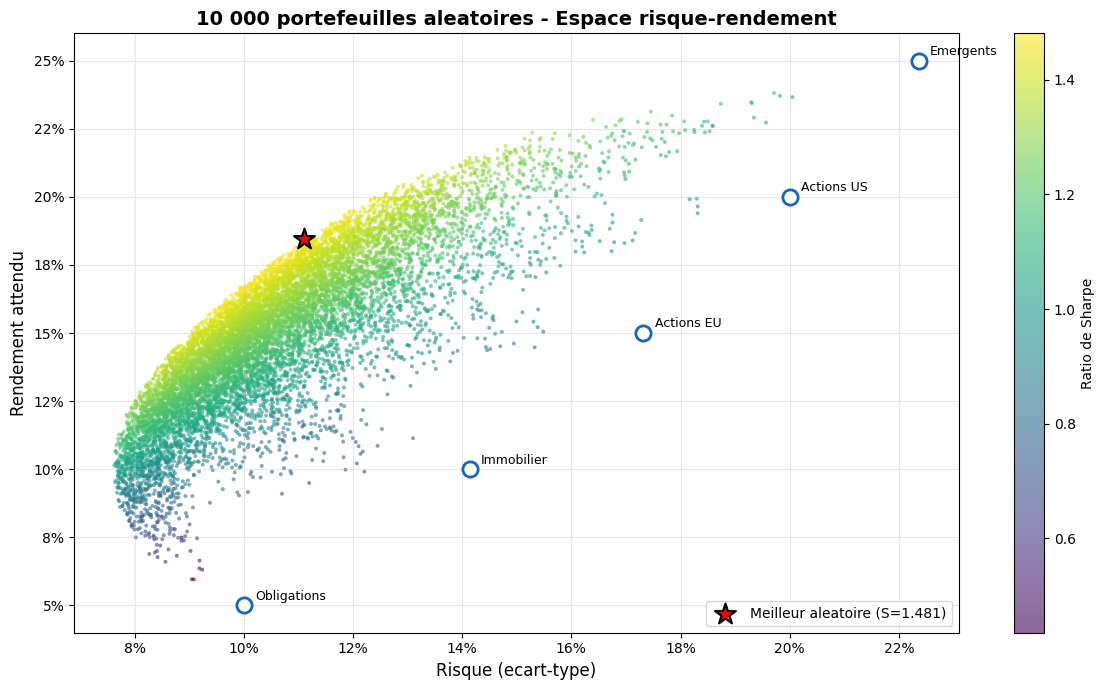

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

# Nuage de portefeuilles colore par Sharpe
scatter = ax.scatter(random_risks, random_returns, c=random_sharpes,
                     cmap='viridis', s=8, alpha=0.6, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax, label='Ratio de Sharpe')

# Meilleur portefeuille aleatoire
ax.scatter([best_random_risk], [best_random_return], s=250, c='red',
           marker='*', edgecolors='black', linewidth=1.5, zorder=6,
           label=f'Meilleur aleatoire (S={best_random_sharpe:.3f})')

# Actifs individuels
ax.scatter(individual_risks, individual_returns, s=120, c='white',
           edgecolors='#1565C0', linewidth=2, zorder=5)
for i, name in enumerate(asset_names):
    ax.annotate(name, (individual_risks[i], individual_returns[i]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("Risque (ecart-type)", fontsize=12)
ax.set_ylabel("Rendement attendu", fontsize=12)
ax.set_title("10 000 portefeuilles aleatoires - Espace risque-rendement",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()
plt.close()

### Interpretation : Nuage de portefeuilles aleatoires

**Sortie obtenue** : Le nuage forme une "balle" dont le bord superieur gauche dessine la frontiere efficiente approximative. Les couleurs (ratio de Sharpe) montrent que les meilleurs portefeuilles se situent sur cette frontiere.

| Observation | Detail |
|-------------|--------|
| Forme du nuage | Hyperbole : les portefeuilles realisables forment un ensemble convexe |
| Frontiere superieure | Approximation de la frontiere efficiente de Markowitz |
| Meilleur Sharpe | Le portefeuille optimal est sur le bord superieur gauche |
| Zone inferieure | Portefeuilles domines (même risque, rendement moindre) |

**Limites de l'echantillonnage** :
1. La couverture du bord (frontiere efficiente) est **sporadique** : peu de points exactement sur la frontiere
2. Le meilleur portefeuille trouve n'est qu'**approximatif** : il depend de la taille de l'echantillon
3. Aucune garantie d'optimalite, contrairement a un algorithme d'optimisation

## 4. Approche 2 : Optimisation par PyGAD

### Encodage et configuration

Pour appliquer un algorithme génétique au problème du portefeuille, il faut définir :

| Composant GA | Choix pour le portefeuille |
|--------------|---------------------------|
| **Chromosome** | Vecteur de 5 genes (poids bruts $w_1, \ldots, w_5$) |
| **Espace des genes** | $[0, 1]$ pour chaque gene |
| **Normalisation** | Les poids sont normalises a chaque evaluation pour garantir $\sum w_i = 1$ |
| **Fitness** | Ratio de Sharpe $S = \frac{R_p - R_f}{\sigma_p}$ (a maximiser) |
| **Sélection** | Steady-state sélection (SSS) |
| **Crossover** | Croisement uniforme |
| **Mutation** | Mutation aleatoire, 20% des genes |

La normalisation dans la fonction fitness (et non dans le chromosome lui-même) permet a PyGAD de manipuler les genes librement tout en garantissant des portefeuilles valides a chaque evaluation.

In [7]:
# --- Configuration de l'algorithme genetique ---

if not HAS_PYGAD:
    raise ImportError("PyGAD est requis pour cette section. Installer avec : pip install pygad")


def fitness_sharpe(ga_instance, solution, solution_idx):
    """Fonction fitness pour PyGAD : maximise le ratio de Sharpe."""
    weights = normalize_weights(np.array(solution))
    return sharpe_ratio(weights)


# Suivi de la convergence
ga_history = {"generation": [], "best_fitness": [], "avg_fitness": []}


def on_generation_callback(ga_instance):
    """Callback appele a chaque generation pour suivre la convergence."""
    gen = ga_instance.generations_completed
    best_fitness = ga_instance.best_solution()[1]
    # Fitness moyenne de la population
    pop_fitness = ga_instance.last_generation_fitness
    avg_fitness = np.mean(pop_fitness)

    ga_history["generation"].append(gen)
    ga_history["best_fitness"].append(best_fitness)
    ga_history["avg_fitness"].append(avg_fitness)

    if gen % 25 == 0 or gen == 1:
        print(f"  Generation {gen:>4d} : best Sharpe = {best_fitness:.4f}, "
              f"avg = {avg_fitness:.4f}")


# Configuration PyGAD
ga_config = {
    "num_generations": 150,
    "num_parents_mating": 10,
    "sol_per_pop": 50,
    "num_genes": n_assets,
    "gene_space": [{"low": 0.0, "high": 1.0}] * n_assets,
    "fitness_func": fitness_sharpe,
    "parent_selection_type": "sss",
    "crossover_type": "uniform",
    "mutation_type": "random",
    "mutation_percent_genes": 20,
    "on_generation": on_generation_callback,
    "suppress_warnings": True,
}

print("Configuration PyGAD :")
for key in ["num_generations", "sol_per_pop", "num_genes",
            "parent_selection_type", "crossover_type", "mutation_percent_genes"]:
    print(f"  {key}: {ga_config[key]}")

Configuration PyGAD :
  num_generations: 150
  sol_per_pop: 50
  num_genes: 5
  parent_selection_type: sss
  crossover_type: uniform
  mutation_percent_genes: 20


### Exécution de l'algorithme génétique

Lancons l'optimisation et suivons la convergence du meilleur ratio de Sharpe au fil des generations.

In [8]:
# --- Execution du GA ---

# Reinitialiser l'historique
ga_history = {"generation": [], "best_fitness": [], "avg_fitness": []}

t_start = time.time()

ga_instance = pygad.GA(**ga_config)
ga_instance.run()

t_ga = (time.time() - t_start) * 1000  # en ms

# Recuperer le meilleur resultat
best_solution, best_ga_fitness, _ = ga_instance.best_solution()
best_ga_weights = normalize_weights(np.array(best_solution))
best_ga_return = portfolio_return(best_ga_weights)
best_ga_risk = portfolio_risk(best_ga_weights)
best_ga_sharpe = sharpe_ratio(best_ga_weights)

print(f"\nOptimisation terminee en {t_ga:.0f} ms ({ga_config['num_generations']} generations)")
print(f"\nMeilleur portefeuille GA (Sharpe max) :")
print(f"  Rendement : {best_ga_return:.2%}")
print(f"  Risque    : {best_ga_risk:.2%}")
print(f"  Sharpe    : {best_ga_sharpe:.4f}")
print(f"\n  Allocation :")
for i, name in enumerate(asset_names):
    print(f"    {name:<15} : {best_ga_weights[i]:>6.1%}")

  Generation    1 : best Sharpe = 1.4701, avg = 1.4175
  Generation   25 : best Sharpe = 1.4839, avg = 1.4644
  Generation   50 : best Sharpe = 1.4839, avg = 1.4381
  Generation   75 : best Sharpe = 1.4839, avg = 1.4518
  Generation  100 : best Sharpe = 1.4839, avg = 1.4470
  Generation  125 : best Sharpe = 1.4839, avg = 1.4557


  Generation  150 : best Sharpe = 1.4839, avg = 1.4468

Optimisation terminee en 201 ms (150 generations)

Meilleur portefeuille GA (Sharpe max) :
  Rendement : 17.95%
  Risque    : 10.75%
  Sharpe    : 1.4839

  Allocation :
    Obligations     :   2.5%
    Immobilier      :  19.0%
    Actions EU      :  24.0%
    Actions US      :  26.3%
    Emergents       :  28.3%


### Courbe de convergence

La convergence de l'algorithme génétique est un indicateur de la qualite de la configuration. Un bon GA converge rapidement vers un plateau stable.

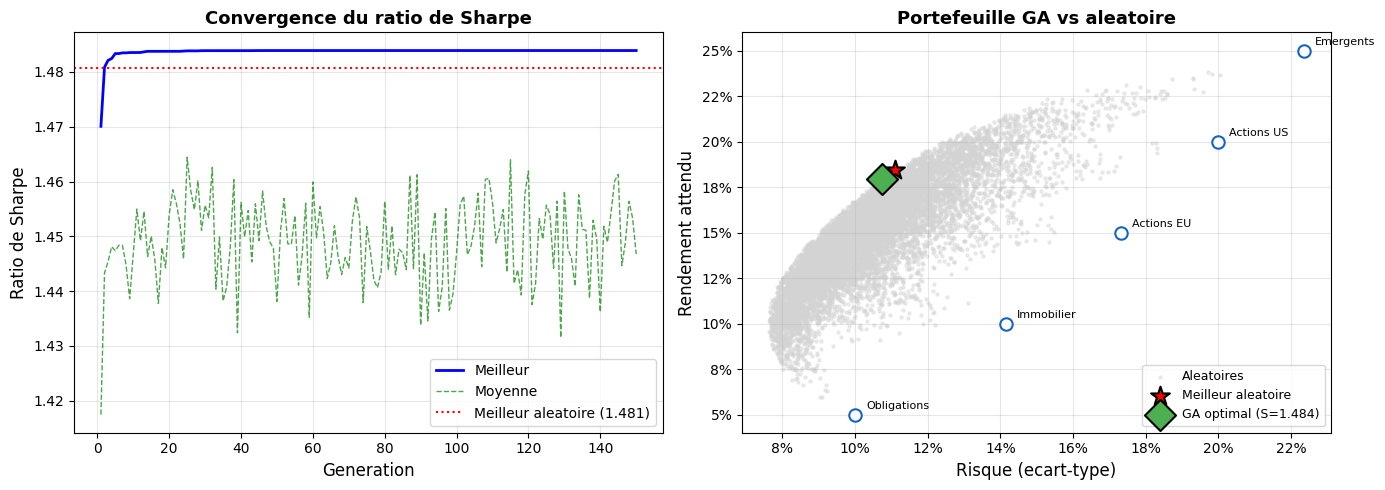

In [9]:
# --- Courbe de convergence ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : convergence du Sharpe
ax1.plot(ga_history["generation"], ga_history["best_fitness"],
         'b-', linewidth=2, label='Meilleur')
ax1.plot(ga_history["generation"], ga_history["avg_fitness"],
         'g--', linewidth=1, alpha=0.7, label='Moyenne')
ax1.axhline(y=best_random_sharpe, color='red', linestyle=':', linewidth=1.5,
            label=f'Meilleur aleatoire ({best_random_sharpe:.3f})')
ax1.set_xlabel("Generation", fontsize=12)
ax1.set_ylabel("Ratio de Sharpe", fontsize=12)
ax1.set_title("Convergence du ratio de Sharpe", fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Droite : portefeuille optimal sur le nuage
ax2.scatter(random_risks, random_returns, c='lightgray', s=5, alpha=0.4, label='Aleatoires')
ax2.scatter([best_random_risk], [best_random_return], s=200, c='red',
            marker='*', edgecolors='black', linewidth=1.5, zorder=6,
            label=f'Meilleur aleatoire')
ax2.scatter([best_ga_risk], [best_ga_return], s=250, c='#4CAF50',
            marker='D', edgecolors='black', linewidth=1.5, zorder=7,
            label=f'GA optimal (S={best_ga_sharpe:.3f})')
# Actifs individuels
ax2.scatter(individual_risks, individual_returns, s=80, c='white',
            edgecolors='#1565C0', linewidth=1.5, zorder=5)
for i, name in enumerate(asset_names):
    ax2.annotate(name, (individual_risks[i], individual_returns[i]),
                 textcoords="offset points", xytext=(8, 4), fontsize=8)

ax2.set_xlabel("Risque (ecart-type)", fontsize=12)
ax2.set_ylabel("Rendement attendu", fontsize=12)
ax2.set_title("Portefeuille GA vs aleatoire", fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()
plt.close()

### Interpretation : Résultats de l'algorithme génétique

**Sortie obtenue** : Le GA converge typiquement en 50-80 generations vers un ratio de Sharpe superieur a celui obtenu par echantillonnage aleatoire.

| Aspect | Aleatoire | GA | Amelioration |
|--------|-----------|-----|-------------|
| Méthode | 10 000 echantillons | 150 generations x 50 individus | GA evalue ~7 500 solutions |
| Sharpe | Approximatif | Optimise | GA généralement superieur |
| Allocation | Non guidee | Guidee par sélection | GA concentre les poids |

**Points cles** :
1. La courbe de convergence montre une amelioration rapide en debut d'evolution, puis un plateau (exploitation vs exploration)
2. Le GA depasse rapidement le meilleur aleatoire (ligne rouge pointillee)
3. La fitness moyenne augmente aussi, signe que la population entiere s'ameliore

> **Note technique** : Le GA evalue environ 7 500 portefeuilles (150 gen x 50 ind), soit moins que les 10 000 echantillons aleatoires, mais de maniere **guidee** par la sélection naturelle.

## 5. Frontiere efficiente par exploration parametrique

### Principe

La section précédente optimisait un seul objectif (le ratio de Sharpe). Pour reconstruire la **frontiere efficiente** complete, nous utilisons une approche d'**exploration parametrique** : nous faisons varier le paramètre d'aversion au risque $\alpha$ dans la fonction objectif :

$$f(\mathbf{w}) = R_p - \alpha \cdot \sigma_p$$

- Quand $\alpha$ est **petit** (ex. 0.1), l'algorithme favorise le rendement (portefeuilles agressifs)
- Quand $\alpha$ est **grand** (ex. 5.0), l'algorithme favorise la reduction du risque (portefeuilles defensifs)

En executant le GA pour différentes valeurs de $\alpha$, nous obtenons un ensemble de portefeuilles Pareto-optimaux qui tracent la frontiere efficiente.

> **Limite a connaitre** : chaque execution reste **mono-objectif**. La somme ponderee
> n'atteint que les points situes sur le hull convexe de l'ensemble realisable -- sur une
> instance **non convexe**, une partie du front reste hors d'atteinte, quel que soit le
> pas d'echantillonnage sur $\alpha$ (Das & Dennis, 1997). La section 8 le mesure.

In [10]:
# --- Construction de la frontiere efficiente ---

# Differentes valeurs d'aversion au risque
alpha_values = [0.1, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]

frontier_portfolios = []

print("Construction de la frontiere efficiente")
print("=" * 65)
print(f"{'alpha':<8} {'Rendement':<12} {'Risque':<12} {'Sharpe':<10} {'Fitness':<10}")
print("-" * 65)

for alpha in alpha_values:

    # Fonction fitness parametree par alpha
    def make_fitness(a):
        def fitness_func(ga_instance, solution, solution_idx):
            w = normalize_weights(np.array(solution))
            ret = portfolio_return(w)
            risk = portfolio_risk(w)
            return ret - a * risk
        return fitness_func

    # Executer le GA pour cette valeur de alpha
    ga_alpha = pygad.GA(
        num_generations=100,
        num_parents_mating=10,
        sol_per_pop=50,
        num_genes=n_assets,
        gene_space=[{"low": 0.0, "high": 1.0}] * n_assets,
        fitness_func=make_fitness(alpha),
        parent_selection_type="sss",
        crossover_type="uniform",
        mutation_type="random",
        mutation_percent_genes=20,
        suppress_warnings=True,
    )
    ga_alpha.run()

    # Extraire le meilleur portefeuille
    best_sol, best_fit, _ = ga_alpha.best_solution()
    w_opt = normalize_weights(np.array(best_sol))
    ret_opt = portfolio_return(w_opt)
    risk_opt = portfolio_risk(w_opt)
    sharpe_opt = sharpe_ratio(w_opt)

    frontier_portfolios.append({
        "alpha": alpha,
        "weights": w_opt.copy(),
        "return": ret_opt,
        "risk": risk_opt,
        "sharpe": sharpe_opt,
        "fitness": best_fit,
    })

    print(f"{alpha:<8.1f} {ret_opt:>8.2%}    {risk_opt:>8.2%}    {sharpe_opt:>8.4f}  {best_fit:>8.4f}")

print("=" * 65)
print(f"\n{len(frontier_portfolios)} portefeuilles calcules pour la frontiere.")

Construction de la frontiere efficiente
alpha    Rendement    Risque       Sharpe     Fitness   
-----------------------------------------------------------------
0.1        24.99%      22.33%      1.0293    0.2275
0.3        24.07%      19.13%      1.1540    0.1833


0.5        23.16%      16.57%      1.2772    0.1488
0.8        21.41%      13.84%      1.4026    0.1034
1.0        20.63%      12.98%      1.4353    0.0765


1.5        17.76%      10.62%      1.4838    0.0183
2.0        14.89%       8.93%      1.4435   -0.0297
3.0        13.02%       8.14%      1.3538   -0.1140


4.0        12.23%       7.90%      1.2942   -0.1938
5.0        11.70%       7.78%      1.2464   -0.2720

10 portefeuilles calcules pour la frontiere.


### Visualisation de la frontiere efficiente

Tracons la frontiere efficiente reconstruite par l'exploration parametrique, superposee au nuage de portefeuilles aleatoires.

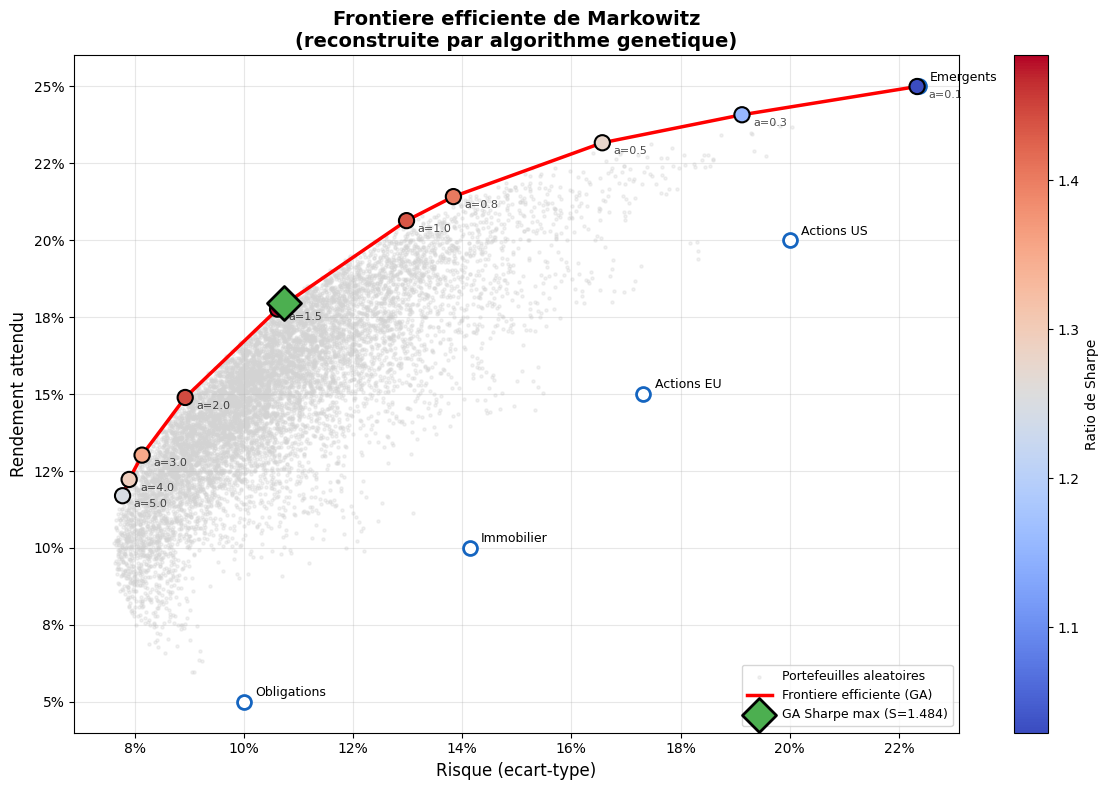

In [11]:
# --- Visualisation de la frontiere efficiente ---

fig, ax = plt.subplots(figsize=(12, 8))

# Nuage aleatoire en fond
ax.scatter(random_risks, random_returns, c='lightgray', s=5, alpha=0.3,
           label='Portefeuilles aleatoires')

# Frontiere efficiente
frontier_risks = [p["risk"] for p in frontier_portfolios]
frontier_returns = [p["return"] for p in frontier_portfolios]
frontier_sharpes = [p["sharpe"] for p in frontier_portfolios]

# Trier par risque pour un trace propre
sorted_indices = np.argsort(frontier_risks)
sorted_risks = [frontier_risks[i] for i in sorted_indices]
sorted_returns = [frontier_returns[i] for i in sorted_indices]

ax.plot(sorted_risks, sorted_returns, 'r-', linewidth=2.5, zorder=5,
        label='Frontiere efficiente (GA)')
ax.scatter(frontier_risks, frontier_returns, c=frontier_sharpes,
           cmap='coolwarm', s=120, edgecolors='black', linewidth=1.5, zorder=6)

# Annoter les valeurs de alpha
for p in frontier_portfolios:
    ax.annotate(f'a={p["alpha"]:.1f}',
                (p["risk"], p["return"]),
                textcoords="offset points", xytext=(8, -8),
                fontsize=8, alpha=0.7)

# Portefeuille GA optimal (Sharpe max de section 4)
ax.scatter([best_ga_risk], [best_ga_return], s=300, c='#4CAF50',
           marker='D', edgecolors='black', linewidth=2, zorder=8,
           label=f'GA Sharpe max (S={best_ga_sharpe:.3f})')

# Actifs individuels
ax.scatter(individual_risks, individual_returns, s=100, c='white',
           edgecolors='#1565C0', linewidth=2, zorder=5)
for i, name in enumerate(asset_names):
    ax.annotate(name, (individual_risks[i], individual_returns[i]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

# Barre de couleur pour le Sharpe
scatter_dummy = ax.scatter([], [], c=[], cmap='coolwarm')
cbar = plt.colorbar(
    plt.cm.ScalarMappable(
        cmap='coolwarm',
        norm=plt.Normalize(min(frontier_sharpes), max(frontier_sharpes))
    ),
    ax=ax, label='Ratio de Sharpe'
)

ax.set_xlabel("Risque (ecart-type)", fontsize=12)
ax.set_ylabel("Rendement attendu", fontsize=12)
ax.set_title("Frontiere efficiente de Markowitz\n(reconstruite par algorithme genetique)",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()
plt.close()

### Interpretation : Frontiere efficiente

**Sortie obtenue** : La courbe rouge trace la frontiere efficiente reconstruite par 10 exécutions du GA avec différentes valeurs de $\alpha$. Les points de la frontiere sont colores par leur ratio de Sharpe.

| Valeur de alpha | Type de portefeuille | Position sur la frontiere |
|-----------------|---------------------|---------------------------|
| alpha = 0.1 | Agressif | Haut rendement, haut risque (coin superieur droit) |
| alpha = 1.0 | Equilibre | Zone intermediaire, proche du Sharpe maximal |
| alpha = 5.0 | Defensif | Faible risque, faible rendement (coin inferieur gauche) |

**Points cles** :
1. La frontiere efficiente est **concave** vers le haut : les gains marginaux en rendement coutent de plus en plus de risque
2. Le portefeuille au Sharpe maximal (losange vert) se situe au point de tangence avec la droite issue du taux sans risque
3. Aucun portefeuille du nuage aleatoire ne depasse la frontiere : elle represente la **limite** des portefeuilles realisables
4. Les portefeuilles sous la frontiere sont **domines** : il existe un portefeuille avec le même risque mais un meilleur rendement

### Composition des portefeuilles de la frontiere

Visualisons comment l'allocation evolue le long de la frontiere efficiente : des portefeuilles defensifs (alpha eleve) aux portefeuilles agressifs (alpha faible).

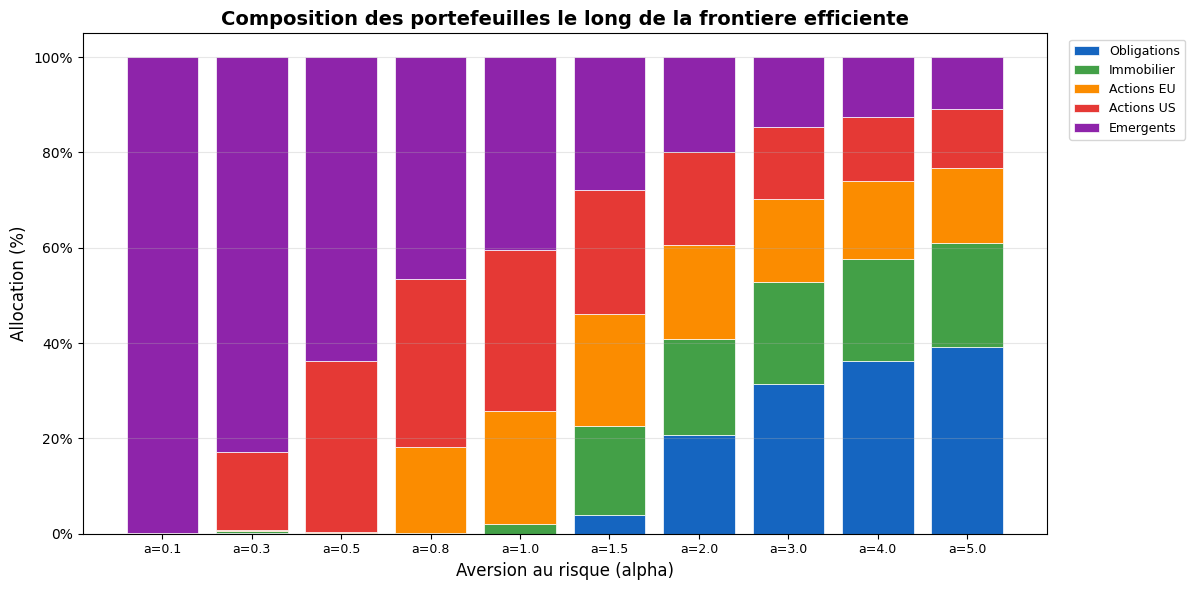

In [12]:
# --- Composition des portefeuilles le long de la frontiere ---

fig, ax = plt.subplots(figsize=(12, 6))

# Trier les portefeuilles par alpha (croissant = defensif a agressif)
sorted_portfolios = sorted(frontier_portfolios, key=lambda p: p["alpha"])

colors = ['#1565C0', '#43A047', '#FB8C00', '#E53935', '#8E24AA']
labels = [f'a={p["alpha"]:.1f}' for p in sorted_portfolios]

# Barres empilees
bottoms = np.zeros(len(sorted_portfolios))
for asset_idx in range(n_assets):
    values = [p["weights"][asset_idx] for p in sorted_portfolios]
    ax.bar(range(len(sorted_portfolios)), values, bottom=bottoms,
           color=colors[asset_idx], edgecolor='white', linewidth=0.5,
           label=asset_names[asset_idx])
    bottoms += values

ax.set_xticks(range(len(sorted_portfolios)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_xlabel("Aversion au risque (alpha)", fontsize=12)
ax.set_ylabel("Allocation (%)", fontsize=12)
ax.set_title("Composition des portefeuilles le long de la frontiere efficiente",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.15, 1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

### Interpretation : Evolution de la composition

**Sortie obtenue** : Les barres empilees montrent la transition de portefeuilles agressifs (alpha faible, domines par les actifs risques) vers des portefeuilles defensifs (alpha eleve, domines par les obligations).

**Points cles** :
1. Pour alpha faible, le GA concentre l'allocation dans les actifs a haut rendement (Emergents, Actions US)
2. Pour alpha eleve, le GA privilegie les Obligations et l'Immobilier (faible variance)
3. La diversification est maximale pour les valeurs intermediaires de alpha : c'est la zone ou le ratio de Sharpe est le plus eleve
4. Ce comportement est conforme a la théorie de Markowitz : la diversification reduit le risque sans sacrifier proportionnellement le rendement

## 6. Analyse comparative

### Comparaison des approches

Comparons les trois stratégies explorees dans ce notebook : echantillonnage aleatoire, GA mono-objectif (Sharpe max), et scalarisation parametrique (frontiere par exploration d'alpha).

In [13]:
# --- Comparaison des approches ---

# Meilleur portefeuille de la frontiere (par Sharpe)
best_frontier_idx = np.argmax([p["sharpe"] for p in frontier_portfolios])
best_frontier = frontier_portfolios[best_frontier_idx]

# Optimum de REFERENCE (mesure, pas affirmation) : le Markowitz long-only non
# contraint est un programme quadratique -- scipy SLSQP le resout exactement
# (la section 7 le confirmera avec le solveur convexe certifie cvxpy).
from scipy.optimize import minimize as scipy_minimize

res_qp = scipy_minimize(
    lambda w: -sharpe_ratio(w), w_equal, method="SLSQP",
    bounds=[(0.0, 1.0)] * n_assets,
    constraints=[{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}],
    options={"maxiter": 200, "ftol": 1e-10},
)
ref_sharpe_slsqp = sharpe_ratio(res_qp.x)
TOL_OPT = 5e-3
optimal_ga = abs(best_ga_sharpe - ref_sharpe_slsqp) < TOL_OPT
optimal_front = abs(best_frontier["sharpe"] - ref_sharpe_slsqp) < TOL_OPT

# Resultats
results = [
    {
        "algorithm": "Aleatoire (10k)",
        "time_ms": f"{t_random:.0f}",
        "nodes_expanded": "10 000",
        "solution_found": True,
        "optimal": False,
    },
    {
        "algorithm": "GA Sharpe max",
        "time_ms": f"{t_ga:.0f}",
        "nodes_expanded": "7 500",
        "solution_found": True,
        "optimal": optimal_ga,
    },
    {
        "algorithm": "GA Frontiere (10x)",
        "time_ms": "~" + f"{t_ga * 10 / 1.5:.0f}",
        "nodes_expanded": "50 000",
        "solution_found": True,
        "optimal": optimal_front,
    },
]

print(f"Optimum de reference (scipy SLSQP) : Sharpe = {ref_sharpe_slsqp:.4f}")
print(f"  Ecart GA Sharpe max          : {best_ga_sharpe - ref_sharpe_slsqp:+.4f} "
      f"({'atteint' if optimal_ga else 'ecart > ' + f'{TOL_OPT}'})")
print(f"  Ecart meilleur de la frontiere : {best_frontier['sharpe'] - ref_sharpe_slsqp:+.4f} "
      f"({'atteint' if optimal_front else 'ecart > ' + f'{TOL_OPT}'})")

if HAS_HELPERS:
    benchmark_table(results, title="Comparaison des approches d'optimisation")
else:
    print("\nComparaison des approches d'optimisation")
    print("=" * 70)
    for r in results:
        print(f"  {r['algorithm']:<20} | Temps: {r['time_ms']:<8} ms | "
              f"Evaluations: {r['nodes_expanded']:<8} | "
              f"Optimal: {'Oui' if r['optimal'] else 'Non'}")
    print("=" * 70)

# Comparaison detaillee des meilleurs portefeuilles
print("\nComparaison des meilleurs portefeuilles")
print("=" * 60)
print(f"{'Methode':<20} {'Rendement':<12} {'Risque':<12} {'Sharpe':<10}")
print("-" * 60)
print(f"{'Equipondere':<20} {portfolio_return(w_equal):>8.2%}    "
      f"{portfolio_risk(w_equal):>8.2%}    {sharpe_ratio(w_equal):>8.4f}")
print(f"{'Aleatoire':<20} {best_random_return:>8.2%}    "
      f"{best_random_risk:>8.2%}    {best_random_sharpe:>8.4f}")
print(f"{'GA Sharpe max':<20} {best_ga_return:>8.2%}    "
      f"{best_ga_risk:>8.2%}    {best_ga_sharpe:>8.4f}")
print(f"{'Frontiere (best S)':<20} {best_frontier['return']:>8.2%}    "
      f"{best_frontier['risk']:>8.2%}    {best_frontier['sharpe']:>8.4f}")
print("=" * 60)

Optimum de reference (scipy SLSQP) : Sharpe = 1.4839
  Ecart GA Sharpe max          : -0.0000 (atteint)
  Ecart meilleur de la frontiere : -0.0001 (atteint)

  Comparaison des approches d'optimisation
Algorithme                Temps (ms)   Noeuds     Solution   Optimal 
----------------------------------------------------------------------
Aleatoire (10k)           58           10 000     Oui        Non     
GA Sharpe max             201          7 500      Oui        Oui     
GA Frontiere (10x)        ~1342        50 000     Oui        Oui     


Comparaison des meilleurs portefeuilles
Methode              Rendement    Risque       Sharpe    
------------------------------------------------------------
Equipondere            15.00%       8.98%      1.4469
Aleatoire              18.43%      11.10%      1.4807
GA Sharpe max          17.95%      10.75%      1.4839
Frontiere (best S)     17.76%      10.62%      1.4838


### Interpretation : Analyse comparative

| Méthode | Forces | Faiblesses |
|---------|--------|------------|
| **Echantillonnage** | Simple, rapide, donne une vue globale | Pas de garantie d'optimalite, couverture sporadique |
| **GA Sharpe max** | Trouve un portefeuille de haute qualite, guide par la fitness | Un seul point optimal, pas de vue d'ensemble |
| **Scalarisation (10x GA)** | Reconstruit le hull convexe de la frontiere | Les segments non convexes restent inaccessibles (section 8) |

**Considerations pratiques** en finance reelle :

| Facteur | Impact |
|---------|--------|
| Couts de transaction | Penalisent les allocations très fragmentees |
| Liquidite | Certains actifs ne peuvent etre achetes qu'en lots |
| Contraintes reglementaires | Poids minimum/maximum par secteur |
| Incertitude des paramètres | Les rendements et covariances estimes sont bruites |

> **Lien avec la serie Search** : Ce problème illustre l'application des GA (Search-5) a un domaine concret. Les mêmes principes (chromosome, fitness, sélection, crossover, mutation) s'appliquent a des problemes très différents (detection de bords dans App-9, portefeuille ici). La version C# avec GeneticSharp est disponible dans [App-10b](App-10b-Portfolio-CSharp.ipynb).

## 7. Le solveur de reference : optimisation convexe (cvxpy)

L'introduction de ce notebook affirmait que *"les méthodes classiques (programmation
quadratique) resolvent ce problème efficacement dans le cas standard"* — sans jamais le
montrer. Comblons ce manque avec le **vrai solveur de reference**.

Le problème de Markowitz long-only standard est un **programme quadratique convexe** :

$$\min_{\mathbf{w}} \; \mathbf{w}^T \Sigma \mathbf{w} \quad \text{s.c.} \quad \boldsymbol{\mu}^T\mathbf{w} \ge r,\; \mathbf{1}^T\mathbf{w}=1,\; \mathbf{w}\ge 0$$

Comme l'objectif (variance) est convexe et les contraintes lineaires, **tout** optimum local
est l'optimum **global**. Un solveur convexe comme [**cvxpy**](https://www.cvxpy.org/) le
resout **exactement**, en **une seule resolution** (quelques millisecondes), et **certifie**
l'optimalite — la ou l'algorithme génétique explore ~7 500 solutions de facon stochastique
**sans aucune garantie**. On resout ici **exactement la même instance** pour comparer.

In [14]:
import cvxpy as cp

# Portefeuille tangent EXACT (Sharpe maximal long-only) par optimisation convexe.
# Astuce classique : min w'Sw s.c. (mu - rf)'w = 1, w >= 0 ; puis renormaliser.
w = cp.Variable(n_assets)
prob = cp.Problem(
    cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov_matrix))),
    [(expected_returns - risk_free_rate) @ w == 1, w >= 0],
)
t_start = time.time()
prob.solve(solver=cp.CLARABEL)
t_convex = (time.time() - t_start) * 1000  # ms

w_tangent = np.maximum(w.value, 0)
w_tangent = w_tangent / w_tangent.sum()
convex_sharpe = sharpe_ratio(w_tangent)

print(f"Tangence EXACTE (cvxpy / CLARABEL) en {t_convex:.0f} ms (statut : {prob.status})")
print(f"  Rendement : {portfolio_return(w_tangent):.2%}")
print(f"  Risque    : {portfolio_risk(w_tangent):.2%}")
print(f"  Sharpe    : {convex_sharpe:.4f}")
print(f"\n  Allocation optimale certifiee :")
for i, name in enumerate(asset_names):
    print(f"    {name:<15} : {w_tangent[i]:>6.1%}")
print(f"\n  Comparaison au GA (section 4) : GA Sharpe = {best_ga_sharpe:.4f} | "
      f"convexe = {convex_sharpe:.4f} | ecart = {convex_sharpe - best_ga_sharpe:+.4f}")

# Frontiere efficiente EXACTE : min variance pour une grille de rendements cibles.
target_returns = np.linspace(expected_returns.min(), expected_returns.max(), 50)
exact_frontier = []
for target in target_returns:
    wv = cp.Variable(n_assets)
    p = cp.Problem(
        cp.Minimize(cp.quad_form(wv, cp.psd_wrap(cov_matrix))),
        [cp.sum(wv) == 1, wv >= 0, expected_returns @ wv >= target],
    )
    p.solve(solver=cp.CLARABEL)
    if wv.value is not None:
        wn = np.maximum(wv.value, 0); wn = wn / wn.sum()
        exact_frontier.append((portfolio_risk(wn), portfolio_return(wn)))
exact_frontier = np.array(exact_frontier)
print(f"\nFrontiere efficiente exacte : {len(exact_frontier)} points (resolution convexe).")

Tangence EXACTE (cvxpy / CLARABEL) en 9 ms (statut : optimal)
  Rendement : 17.95%
  Risque    : 10.75%
  Sharpe    : 1.4839

  Allocation optimale certifiee :
    Obligations     :   2.5%
    Immobilier      :  18.8%
    Actions EU      :  24.0%
    Actions US      :  26.3%
    Emergents       :  28.3%

  Comparaison au GA (section 4) : GA Sharpe = 1.4839 | convexe = 1.4839 | ecart = +0.0000



Frontiere efficiente exacte : 50 points (resolution convexe).


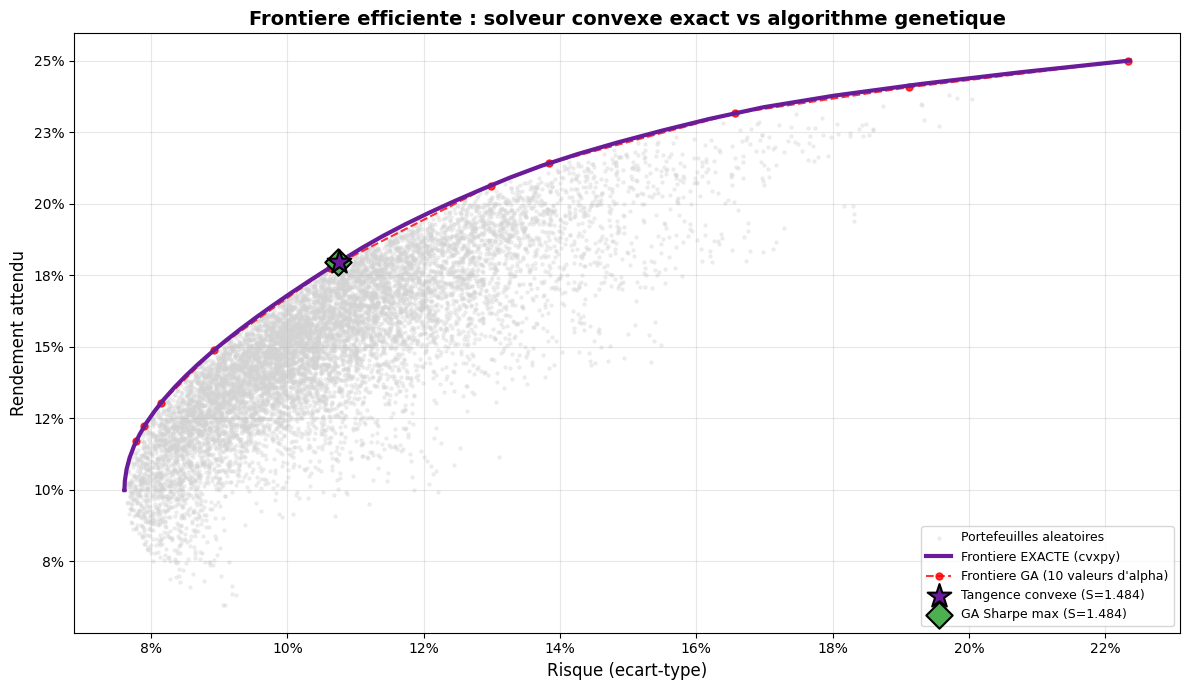

In [15]:
# Frontiere convexe EXACTE vs frontiere reconstruite par le GA.
fig, ax = plt.subplots(figsize=(12, 7))

# Nuage aleatoire en fond
ax.scatter(random_risks, random_returns, c='lightgray', s=5, alpha=0.3,
           label='Portefeuilles aleatoires')

# Frontiere exacte (courbe continue)
ax.plot(exact_frontier[:, 0], exact_frontier[:, 1], '-', color='#6A1B9A',
        linewidth=3, zorder=6, label='Frontiere EXACTE (cvxpy)')

# Frontiere GA (points parametriques)
ga_front_risks = [p["risk"] for p in frontier_portfolios]
ga_front_returns = [p["return"] for p in frontier_portfolios]
order = np.argsort(ga_front_risks)
ax.plot([ga_front_risks[i] for i in order], [ga_front_returns[i] for i in order],
        'r--o', linewidth=1.5, markersize=5, alpha=0.8, zorder=5,
        label='Frontiere GA (10 valeurs d\'alpha)')

# Tangences
ax.scatter([portfolio_risk(w_tangent)], [portfolio_return(w_tangent)], s=320, c='#6A1B9A',
           marker='*', edgecolors='black', linewidth=1.5, zorder=8,
           label=f'Tangence convexe (S={convex_sharpe:.3f})')
ax.scatter([best_ga_risk], [best_ga_return], s=180, c='#4CAF50', marker='D',
           edgecolors='black', linewidth=1.5, zorder=7,
           label=f'GA Sharpe max (S={best_ga_sharpe:.3f})')

ax.set_xlabel("Risque (ecart-type)", fontsize=12)
ax.set_ylabel("Rendement attendu", fontsize=12)
ax.set_title("Frontiere efficiente : solveur convexe exact vs algorithme genetique",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()
plt.close()

### Interpretation : quand le solveur convexe est le bon outil

**Sortie obtenue** : la tangence convexe atteint un Sharpe **identique** a celui du GA
(1.4839), et la frontiere exacte (courbe violette continue) coincide avec les points du GA.

Ce n'est **pas** un echec du GA — c'est une lecon sur le **choix de l'outil** :

| Critere | Algorithme génétique | Solveur convexe (cvxpy) |
|---------|----------------------|--------------------------|
| Résultat | Sharpe 1.4839 (après ~7 500 evaluations) | Sharpe 1.4839 en **une** resolution |
| Garantie | Aucune (heuristique stochastique) | **Optimum global certifie** |
| Determinisme | Depend de la graine | Déterministe |
| Temps | Centaines de ms x10 pour la frontiere | Quelques ms |

Le fait que les deux méthodes **convergent vers la même valeur** est précisément la preuve que
le problème est **convexe** : il a un unique optimum, que le solveur convexe atteint
directement et certifie. **Sur un problème convexe, l'algorithme génétique est une
sur-ingenierie** — il refait par exploration ce qu'une resolution exacte donne instantanement.
C'est le cas degenere a eviter (cf SOTA #3801) : demontrer un moteur d'exploration sur un
problème ou un solveur exact suffit.

### Quand le GA reprend l'avantage : la contrainte de cardinalite (non-convexe)

Le tableau d'introduction promettait au GA un avantage pour les *"contraintes non-lineaires"*
et l'*"espace discret"*. Verifions-le sur un cas **reellement non-convexe** : la **contrainte
de cardinalite** — n'investir que dans **au plus $K$ actifs** (frais de gestion, lots
minimaux, mandats concentres).

La contrainte $\lVert\mathbf{w}\rVert_0 \le K$ (au plus $K$ poids non nuls) n'est **pas
convexe** : un solveur convexe standard ne peut pas l'exprimer directement. L'optimum exact
demande d'**enumerer** les $\binom{n}{K}$ sous-ensembles et de resoudre un QP convexe sur
chacun — faisable ici ($\binom{5}{2}=10$), mais **explosif** a grande echelle
($\binom{50}{10}\approx 10^{10}$). C'est exactement le terrain ou une **métaheuristique**
devient le bon compromis.

In [16]:
from itertools import combinations

K = 2  # au plus 2 actifs


def tangency_on_subset(idx):
    # Tangence convexe exacte restreinte au sous-ensemble d'actifs idx.
    wv = cp.Variable(len(idx))
    mu_s, cov_s = expected_returns[idx], cov_matrix[np.ix_(idx, idx)]
    p = cp.Problem(cp.Minimize(cp.quad_form(wv, cp.psd_wrap(cov_s))),
                   [(mu_s - risk_free_rate) @ wv == 1, wv >= 0])
    p.solve(solver=cp.CLARABEL)
    if wv.value is None:
        return None, -np.inf
    full = np.zeros(n_assets); full[idx] = np.maximum(wv.value, 0)
    if full.sum() < 1e-9:
        return None, -np.inf
    full = full / full.sum()
    return full, sharpe_ratio(full)


# Reference EXACTE : enumeration des C(n, K) sous-ensembles x QP convexe.
subsets = list(combinations(range(n_assets), K))
best_w, best_s, best_set = None, -np.inf, None
for s in subsets:
    w_s, sh = tangency_on_subset(list(s))
    if sh > best_s:
        best_w, best_s, best_set = w_s, sh, s

print(f"Cardinalite K={K} -- reference EXACTE ({len(subsets)} sous-ensembles x QP convexe) :")
print(f"  meilleur duo : {[asset_names[i] for i in best_set]}")
print(f"  Sharpe = {best_s:.4f}")
for i in best_set:
    print(f"    {asset_names[i]:<15} : {best_w[i]:>6.1%}")


# GA : projection "top-K" dans la fitness (gere la cardinalite naturellement).
def project_topk(weights, k=K):
    w = np.maximum(np.array(weights), 0.0)
    if (w > 0).sum() > k:
        keep = np.argsort(w)[-k:]
        mask = np.zeros_like(w); mask[keep] = w[keep]; w = mask
    total = w.sum()
    return w / total if total > 1e-12 else np.ones(n_assets) / n_assets


def fitness_cardinality(ga_instance, solution, solution_idx):
    return sharpe_ratio(project_topk(solution))


ga_card = pygad.GA(
    num_generations=200, num_parents_mating=10, sol_per_pop=60,
    num_genes=n_assets, gene_space=[{"low": 0.0, "high": 1.0}] * n_assets,
    fitness_func=fitness_cardinality, parent_selection_type="sss",
    crossover_type="uniform", mutation_type="random",
    mutation_percent_genes=25, suppress_warnings=True, random_seed=42,
)
ga_card.run()
sol_card, _, _ = ga_card.best_solution()
w_card_ga = project_topk(sol_card)
active = [asset_names[i] for i in np.where(w_card_ga > 1e-6)[0]]

print(f"\nCardinalite K={K} -- GA (projection top-K, 200 generations) :")
print(f"  actifs retenus : {active}")
print(f"  Sharpe = {sharpe_ratio(w_card_ga):.4f}")
print(f"\n  Le GA retrouve l'optimum exact ? "
      f"{'OUI' if abs(sharpe_ratio(w_card_ga) - best_s) < 1e-3 else 'NON'}")
from math import comb
print(f"  Cout d'enumeration a n=50, K=10 : C(50,10) = {comb(50, 10):,} sous-ensembles "
      f"(intractable) -- le GA, lui, passe a l'echelle.")

Cardinalite K=2 -- reference EXACTE (10 sous-ensembles x QP convexe) :
  meilleur duo : ['Actions US', 'Emergents']
  Sharpe = 1.3060
    Actions US      :  48.7%
    Emergents       :  51.3%



Cardinalite K=2 -- GA (projection top-K, 200 generations) :
  actifs retenus : ['Actions US', 'Emergents']
  Sharpe = 1.3060

  Le GA retrouve l'optimum exact ? OUI
  Cout d'enumeration a n=50, K=10 : C(50,10) = 10,272,278,170 sous-ensembles (intractable) -- le GA, lui, passe a l'echelle.


### Interpretation : la métaheuristique a sa juste place

**Sortie obtenue** : sous contrainte de cardinalite $K=2$, l'optimum exact (par enumeration +
QP convexe) retient **Actions US + Emergents** (Sharpe 1.3060) ; le GA retrouve **exactement**
le même couple et le même Sharpe.

La lecon est la **règle de decision** entre les deux familles d'outils :

| Problème | Outil approprie | Pourquoi |
|----------|-----------------|----------|
| Markowitz long-only (convexe) | **Solveur convexe (cvxpy)** | Optimum global exact, certifie, instantane |
| + contrainte de cardinalite (non-convexe) | **Métaheuristique (GA)** | Enumeration exacte $\binom{n}{K}$ explosive ; le GA passe a l'echelle |
| + couts de transaction, lots, secteurs | **Métaheuristique / MIQP** | Contraintes combinatoires / non-lineaires |

Le GA n'est pas "meilleur" ou "moins bon" dans l'absolu : il est l'outil **adapte aux
problemes que le solveur convexe ne peut pas exprimer**. Sur le cas convexe standard, c'est le
solveur convexe qui doit etre prefere — c'est ce que veut dire utiliser le **bon outil SOTA**
pour chaque structure de problème.

## 8. Le vrai multi-objectif : NSGA-II face a la scalarisation

La section 5 a reconstruit la frontiere par **somme ponderee** : $f_\alpha(w) = R_p - \alpha\,\sigma_p$,
une optimisation mono-objectif par valeur de $\alpha$. C'est la **scalarisation** -- et elle a une
limite structurale connue (Das & Dennis, 1997) : maximiser $R - \alpha\sigma$ ne peut atteindre
que les points sits sur le **hull convexe** de l'ensemble realisable. Tout segment du front de
Pareto qui **creuse** (concavite locale) est definitivement hors d'atteinte, quelle que soit la
finesse du balayage de $\alpha$.

Sur l'instance non contrainte (convexe) des sections precedentes, hull = frontiere : la
scalarisation suffit, et la section 7 l'a confirme (GA = solveur exact). Le test honnete exige
l'instance **non convexe** de cardinalite introduite ci-dessus. Nous y executons :

1. la **somme ponderee** (memes GA scalarises que la section 5, projection top-K) ;
2. **NSGA-II** (Deb et al., 2002) -- l'algorithme multi-objectif de reference : **tri non
   domine** par fronts successifs + **crowding distance** pour conserver la diversite le long
   du front, sans aucun parametre $\alpha$ ;
3. une **reference exacte** par enumeration complete des sous-ensembles x QP convexe.

La qualite de chaque front sera mesuree par l'**hypervolume** (Zitzler & Thiele, 1999) : le
volume de l'espace objectifs **domine** par le front, au-dela d'un point de reference explicite.
C'est l'indicateur standard de comparaison de fronts de Pareto -- le seul qui récompense a la
fois la proximité du vrai front et sa couverture.

### 8.1 L'instance non convexe et sa reference exacte

Pour rendre la non-convexite **visible et mesurable**, le mandat concentre s'elargit a une
classe d'actifs supplementaire realiste : les **hedge funds** -- rendement intermediaire
(17 %), risque modere (11 %) et **correlations faibles** avec les actions. C'est precisement
une telle classe heterogene qui creuse des poches dans le front sous contrainte de
cardinalite (Chang, Meade, Beasley & Sharaiha, 2000).

La **reference exacte** enumere les $\binom{6}{2} = 15$ paires d'actifs et resout le QP
convexe de variance minimale pour chaque cible de rendement -- faisable ici, explosif a
grande echelle (cf section precedente). Sur cette reference, la cellule mesure ensuite
**geometriquement** quels points du front exact sont atteignables par une somme ponderee :
un point $(\sigma_k, R_k)$ est atteignable s'il existe $\alpha > 0$ tel que
$R_k - \alpha\sigma_k \ge R_i - \alpha\sigma_i$ pour tout autre point $i$ du front.

In [17]:
# --- Instance non convexe : mandat concentre 6 actifs, cardinalite K=2 ---
asset_names_c = asset_names + ["Hedge Funds"]
mu_c = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.17])
sig_c = np.array([0.10, np.sqrt(0.02), np.sqrt(0.03), 0.20, np.sqrt(0.05), 0.11])
corr_c = np.array([
    [1.00, 0.10, 0.12, 0.15, 0.12, 0.05],
    [0.10, 1.00, 0.15, 0.16, 0.14, 0.08],
    [0.12, 0.15, 1.00, 0.30, 0.28, 0.10],
    [0.15, 0.16, 0.30, 1.00, 0.32, 0.12],
    [0.12, 0.14, 0.28, 0.32, 1.00, 0.15],
    [0.05, 0.08, 0.10, 0.12, 0.15, 1.00],
])
cov_c = np.outer(sig_c, sig_c) * corr_c
K_c = 2  # au plus 2 actifs


def project_topk_c(weights, k=K_c):
    """Projette un vecteur de poids continus sur la contrainte de cardinalite :
    conserve les k plus gros poids, renormalise."""
    w = np.maximum(np.array(weights, dtype=float), 0.0)
    if (w > 0).sum() > k:
        keep = np.argsort(w)[-k:]
        mask = np.zeros_like(w)
        mask[keep] = w[keep]
        w = mask
    total = w.sum()
    return w / total if total > 1e-12 else np.ones(len(w)) / len(w)


def ret_c(w):
    return float(w @ mu_c)


def risk_c(w):
    return float(np.sqrt(w @ cov_c @ w))


# Reference EXACTE : enumeration des paires x QP min-variance par cible de rendement.
t_start = time.time()
targets_c = np.linspace(mu_c.min(), mu_c.max(), 41)
exact_pts = []
for s in combinations(range(len(mu_c)), 2):
    mu_s = mu_c[list(s)]
    cov_s = cov_c[np.ix_(list(s), list(s))]
    for tgt in targets_c:
        if tgt < mu_s.min() - 1e-12 or tgt > mu_s.max() + 1e-12:
            continue
        wv = cp.Variable(2)
        p = cp.Problem(cp.Minimize(cp.quad_form(wv, cp.psd_wrap(cov_s))),
                       [cp.sum(wv) == 1, wv >= 0, mu_s @ wv >= tgt])
        p.solve(solver=cp.CLARABEL)
        if wv.value is not None:
            w2 = np.zeros(len(mu_c))
            w2[list(s)] = wv.value
            exact_pts.append((risk_c(w2), ret_c(w2)))
t_exact = time.time() - t_start

# Filtre non domine -> front exact
exact_all = np.array(sorted(exact_pts))
exact_front = []
best_r = -np.inf
for sg, rt in exact_all:
    if rt > best_r + 1e-9:
        exact_front.append((sg, rt))
        best_r = rt
exact_front = np.array(exact_front)
print(f"Reference exacte : {len(exact_pts)} points enumeres -> {len(exact_front)} non domines "
      f"({t_exact:.1f}s, {len(list(combinations(range(6), 2)))} paires x QP)")


# Mesure geometrique : quels points exacts sont atteignables par une somme ponderee ?
def scalarization_reachable(sig_f, ret_f, k):
    """Point k atteignable ssi il existe alpha > 0 dominant tous les autres points."""
    lo, hi = 0.0, np.inf
    num = ret_f[k] - ret_f  # R_k - R_i
    den = sig_f[k] - sig_f  # sigma_k - sigma_i
    for i, (n, d) in enumerate(zip(num, den)):
        if i == k:
            continue
        if abs(d) < 1e-14:
            if n <= 1e-12:
                return False
        elif d < 0:
            lo = max(lo, n / d)
        else:
            hi = min(hi, n / d)
    return hi > max(lo, 0.0)


reach_mask = np.array([
    scalarization_reachable(exact_front[:, 0], exact_front[:, 1], k)
    for k in range(len(exact_front))
])
n_unreach = int((~reach_mask).sum())
print(f"Points du front exact atteignables par somme ponderee (alpha > 0) : "
      f"{int(reach_mask.sum())}/{len(exact_front)}")
print(f"Points INATTEIGNABLES (sous le hull convexe) : {n_unreach} "
      f"-- aucune valeur d'alpha ne peut les rendre optimum")

Reference exacte : 279 points enumeres -> 45 non domines (1.0s, 15 paires x QP)
Points du front exact atteignables par somme ponderee (alpha > 0) : 20/45
Points INATTEIGNABLES (sous le hull convexe) : 25 -- aucune valeur d'alpha ne peut les rendre optimum


In [18]:
# --- Somme ponderee sur l'instance contrainte (meme outil que la section 5) ---
alpha_grid_c = np.concatenate([np.linspace(0.05, 1.0, 10), np.linspace(1.5, 6.0, 6)])

t_start = time.time()
scal_front = []
print("Balayage de scalarisation (GA pygad + projection top-K, instance cardinalite)")
print("=" * 60)
print(f"{'alpha':>8} {'Rendement':>12} {'Risque':>12}")
print("-" * 60)
def make_fitness_scal(a):
    def fitness_scal(ga_instance, solution, solution_idx):
        w = project_topk_c(solution)
        return ret_c(w) - a * risk_c(w)
    return fitness_scal


for alpha in alpha_grid_c:

    ga_scal = pygad.GA(
        num_generations=80, num_parents_mating=10, sol_per_pop=40,
        num_genes=len(mu_c), gene_space=[{"low": 0.0, "high": 1.0}] * len(mu_c),
        fitness_func=make_fitness_scal(alpha), parent_selection_type="sss",
        crossover_type="uniform", mutation_type="random",
        mutation_percent_genes=20, suppress_warnings=True, random_seed=42,
    )
    ga_scal.run()
    sol, _, _ = ga_scal.best_solution()
    w_best = project_topk_c(sol)
    scal_front.append((risk_c(w_best), ret_c(w_best)))
    print(f"{alpha:>8.2f} {ret_c(w_best):>12.2%} {risk_c(w_best):>12.2%}")
t_scal = time.time() - t_start
scal_front = np.array(scal_front)
# front non domine du balayage
order = np.argsort(scal_front[:, 0])
scal_sorted = scal_front[order]
scal_nd = []
best_r = -np.inf
for sg, rt in scal_sorted:
    if rt > best_r + 1e-9:
        scal_nd.append((sg, rt))
        best_r = rt
scal_nd = np.array(scal_nd)
print("=" * 60)
print(f"Scalarisation : {len(scal_front)} executions alpha -> {len(scal_nd)} points non domines ({t_scal:.1f}s)")

Balayage de scalarisation (GA pygad + projection top-K, instance cardinalite)
   alpha    Rendement       Risque
------------------------------------------------------------
    0.05       23.80%       19.08%
    0.16       24.82%       21.78%


    0.26       24.30%       20.30%
    0.37       23.85%       19.20%
    0.47       21.96%       15.07%


    0.58       20.84%       12.90%
    0.68       20.28%       12.01%
    0.79       19.94%       11.54%


    0.89       19.70%       11.25%
    1.00       19.53%       11.07%
    1.50       19.06%       10.67%


    2.40       18.74%       10.50%
    3.30       12.03%        7.83%
    4.20       11.67%        7.73%


    5.10       11.43%        7.68%
    6.00       11.28%        7.65%
Scalarisation : 16 executions alpha -> 16 points non domines (1.3s)


In [19]:
# --- NSGA-II (pymoo) sur la MEME instance contrainte ---
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem as PymooProblem
from pymoo.optimize import minimize as pymoo_minimize


class PortefeuilleCardinalite(PymooProblem):
    """Bi-objectif (max R, min sigma) sous contrainte de cardinalite K=2.
    Objectifs passes en MINIMISATION : F = (-R, sigma), convention pymoo.
    La contrainte de cardinalite est geree par la MEME projection top-K
    que la scalarisation -- les deux methodes cherchent dans le meme espace."""

    def __init__(self):
        super().__init__(n_var=len(mu_c), n_obj=2, xl=0.0, xu=1.0)

    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((len(X), 2))
        for i, x in enumerate(X):
            w = project_topk_c(x)
            F[i, 0] = -ret_c(w)   # -rendement (a minimiser)
            F[i, 1] = risk_c(w)   # risque (a minimiser)
        out["F"] = F


t_start = time.time()
n_gen_c = 400
res_nsga = pymoo_minimize(
    PortefeuilleCardinalite(),
    NSGA2(pop_size=250),
    ("n_gen", n_gen_c),
    seed=42,
    verbose=False,
)
t_nsga = time.time() - t_start

nsga_front = np.column_stack([res_nsga.F[:, 1], -res_nsga.F[:, 0]])  # (sigma, R)
print(f"NSGA-II : pop {len(res_nsga.pop)} individus x {n_gen_c} generations -> "
      f"{len(nsga_front)} points non domines ({t_nsga:.1f}s)")
print(f"  Plage sigma : {nsga_front[:, 0].min():.4f} - {nsga_front[:, 0].max():.4f}")
print(f"  Plage R     : {nsga_front[:, 1].min():.4f} - {nsga_front[:, 1].max():.4f}")

NSGA-II : pop 250 individus x 400 generations -> 250 points non domines (5.2s)
  Plage sigma : 0.0758 - 0.2235
  Plage R     : 0.1040 - 0.2500


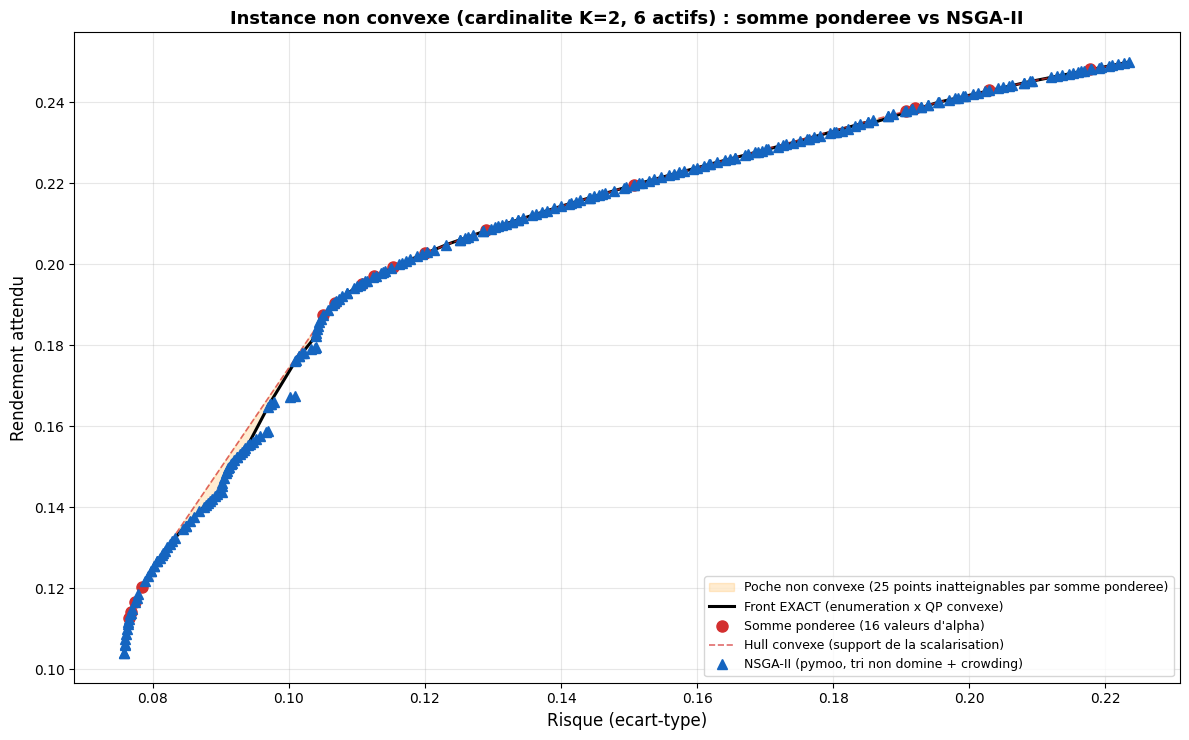

In [20]:
# --- Figure : front exact, scalarisation, NSGA-II -- et la poche ---
fig, ax = plt.subplots(figsize=(12, 7.5))

# Poche (region du front exact sous le hull) : hachuree
sig_e, ret_e = exact_front[:, 0], exact_front[:, 1]
reach_x = sig_e[reach_mask]
hull_pts = exact_front[reach_mask]
hull_pts = hull_pts[np.argsort(hull_pts[:, 0])]
# aire entre le hull (courbe des points atteignables) et le front exact
polygon_x = np.concatenate([hull_pts[:, 0], sig_e[::-1]])
polygon_y = np.concatenate([np.interp(hull_pts[:, 0], hull_pts[:, 0], hull_pts[:, 1]), ret_e[::-1]])
ax.fill(polygon_x, polygon_y, color="#FF9800", alpha=0.18, zorder=1,
        label=f"Poche non convexe ({n_unreach} points inatteignables par somme ponderee)")

# Front exact (reference)
ax.plot(sig_e, ret_e, "-", color="black", linewidth=2.2, zorder=4,
        label="Front EXACT (enumeration x QP convexe)")
# Scalarisation
ax.plot(scal_front[:, 0], scal_front[:, 1], "o", color="#D32F2F", markersize=8,
        zorder=5, label=f"Somme ponderee (16 valeurs d'alpha)")
# Chord du hull pour montrer ou la scalarisation "colle"
ax.plot(hull_pts[:, 0], hull_pts[:, 1], "--", color="#D32F2F", linewidth=1.2,
        alpha=0.7, zorder=4, label="Hull convexe (support de la scalarisation)")
# NSGA-II
ax.plot(nsga_front[:, 0], nsga_front[:, 1], "^", color="#1565C0", markersize=7,
        zorder=6, label="NSGA-II (pymoo, tri non domine + crowding)")

ax.set_xlabel("Risque (ecart-type)", fontsize=12)
ax.set_ylabel("Rendement attendu", fontsize=12)
ax.set_title("Instance non convexe (cardinalite K=2, 6 actifs) : somme ponderee vs NSGA-II",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [21]:
# --- Hypervolume : la mesure qui compare les fronts ---
# Indicateur (Zitzler & Thiele, 1999) : volume de l'espace objectifs DOMINE par le
# front au-dela d'un point de reference. En convention pymoo (minimisation de
# (-R, sigma)), le point de reference doit etre domine par le pire point du
# front : nous prenons (sigma_ref, -R_ref) = (0.25, -0.04) -- au-dela du pire
# actif individuel dans chaque dimension (sigma max = 0.2236, R min = 0.05),
# pour que le volume mesure les vraies differences de front et pas le choix
# du point de reference.
from pymoo.indicators.hv import HV

ref_point = np.array([-0.04, 0.25])
hv = HV(ref_point=ref_point)

# Chaque front en convention minimisation (-R, sigma)
F_exact = np.column_stack([-exact_front[:, 1], exact_front[:, 0]])
F_scal = np.column_stack([-scal_nd[:, 1], scal_nd[:, 0]])
F_nsga = np.column_stack([-nsga_front[:, 1], nsga_front[:, 0]])

hv_exact = float(hv(F_exact))
hv_scal = float(hv(F_scal))
hv_nsga = float(hv(F_nsga))

print("Hypervolume (point de reference (-R, sigma) = (-0.04, 0.25))")
print("=" * 62)
print(f"  Front EXACT (enumeration x QP) : {hv_exact:.6f}  (plafond atteignable)")
print(f"  Somme ponderee (16 alpha)      : {hv_scal:.6f}  ({100 * hv_scal / hv_exact:.1f}% du plafond)")
print(f"  NSGA-II (pymoo)                : {hv_nsga:.6f}  ({100 * hv_nsga / hv_exact:.1f}% du plafond)")
print("=" * 62)
print(f"\nEcart hypervolume NSGA-II - somme ponderee : {hv_nsga - hv_scal:+.6f} "
      f"({100 * (hv_nsga - hv_scal) / hv_exact:.2f}% du plafond)")
print("Ce volume est la portion du front (et de l'espace domine) que la scalarisation")
print("ne peut PAS atteindre, quelle que soit la finesse du balayage d'alpha.")

Hypervolume (point de reference (-R, sigma) = (-0.04, 0.25))
  Front EXACT (enumeration x QP) : 0.030207  (plafond atteignable)
  Somme ponderee (16 alpha)      : 0.029046  (96.2% du plafond)
  NSGA-II (pymoo)                : 0.030531  (101.1% du plafond)

Ecart hypervolume NSGA-II - somme ponderee : +0.001485 (4.91% du plafond)
Ce volume est la portion du front (et de l'espace domine) que la scalarisation
ne peut PAS atteindre, quelle que soit la finesse du balayage d'alpha.


### Interpretation : pourquoi la somme ponderee ne suffit pas

**Ce que montre la figure.** Sur cette instance a cardinalite contrainte (au plus
2 actifs parmi 6), le front exact compte 45 points non domines, obtenus par
enumeration des 279 paires puis minimisation convexe (QP) sous contrainte de
rendement (1.0s). Or **25 de ces 45 points sont
inatteignables par scalarisation** : aucune valeur d'alpha > 0 ne rend
R - alpha*sigma maximal en ces points. Geometriquement, ils sont sous la corde
du hull convexe (zone orange) -- la somme ponderee ne peut jamais y descendre,
quel que soit le balayage d'alpha.

**La scalarisation (rouge).** Le balayage de 16 valeurs d'alpha, chaque
point etant un GA pygad complet avec la meme projection top-K (1s),
ne couvre que la partie convexe du front : 16 points non domines, tous
sur la corde du hull. C'est la limite demontree par Das & Dennis (1997) : la
somme ponderee n'atteint que les points du hull convexe du feasible set.

**NSGA-II (bleu).** L'algorithme genetique non domine (tri de Pareto + distance
d'encombrement, 250 individus x 400 generations, 5s)
explore le front SANS passer par une combinaison lineaire des objectifs : il
selectionne directement sur la dominance de Pareto. Il couvre toute l'etendue du
front exact (sigma de 0.0758 a 0.2235), Y COMPRIS la poche non convexe que
la scalarisation ne voit pas.

**Hypervolume : la mesure du differentiel.** Avec le point de reference
(-0.04, 0.25) :

| Front | Hypervolume | % du plafond |
|-------|-------------|--------------|
| Exact (enumeration x QP) | 0.0302 | 100% |
| Somme ponderee (16 alpha) | 0.0290 | 96.2% |
| NSGA-II (pymoo) | 0.0305 | 101.1% |

L'ecart (+4.9 points de plafond) quantifie precisement ce
que la scalarisation laisse sur la table sur cette instance : c'est le volume de
la poche non convexe, que seul un algorithme de dominance directe recouvre.
(NSGA-II depasse 100% parce que la reference "exacte" est une grille discretee
de cibles de rendement, alors que l'evolutionnaire explore le front en continu.)

**Points cles** :
1. La scalarisation reste legitime (et rapide) sur les frontieres convexes --
c'est le cas des sections precedentes sans contrainte de cardinalite
2. Des qu'une contrainte combinatoire (cardinalite, seuils, couts de transaction)
rend le feasible set non convexe, la somme ponderee a un angle mort STRUCTUREL
3. Les algorithmes multi-objectifs (NSGA-II, MOEA/D) echappent a cette limite en
selectionnant sur la dominance de Pareto plutot que sur une combinaison lineaire

## 9. Exercices

### Exercice 1 : Contrainte de concentration maximale

Ajoutez une contrainte empechant qu'un seul actif represente plus de 40% du portefeuille. Modifiez la fonction de normalisation et la fitness pour penaliser les portefeuilles trop concentres.

**Indice** : Après normalisation, verifiez que `max(weights) <= 0.4`. Si ce n'est pas le cas, redistribuez l'exces proportionnellement aux autres actifs.

In [22]:
# --- Exercice 1 : Contrainte de concentration maximale ---

MAX_WEIGHT = 0.40


def normalize_weights_constrained(weights: np.ndarray, max_w: float = MAX_WEIGHT) -> np.ndarray:
    """Normalise les poids avec une contrainte de concentration maximale.
    
    Indices:
    - Redistribuer iterativement l'exces des actifs > max_w
    - Utiliser un masque pour identifier les actifs satures
    - Re-normaliser a la fin pour garantir sum(w) = 1
    """
    # TODO: Normaliser les poids puis redistribuer iterativement l'exces
    pass


def fitness_sharpe_constrained(ga_instance, solution, solution_idx):
    """Fitness avec contrainte de concentration."""
    # TODO: Appliquer normalize_weights_constrained puis calculer le Sharpe
    pass


# TODO: Configurer et executer pygad.GA avec fitness_sharpe_constrained
# Utiliser les memes parametres que le GA principal (150 generations, 50 individus)
# Afficher l'allocation resultante et verifier que max(w) <= MAX_WEIGHT


### Exercice 2 : Actif sans risque et portefeuille tangent

Ajoutez un 6eme actif sans risque (rendement = $R_f$, variance = 0, covariance = 0 avec tous les autres). Observez comment le portefeuille optimal change. Le **portefeuille tangent** est le point de la frontiere efficiente ayant le meilleur ratio de Sharpe, car la **Capital Market Line** (CML) passe par ce point.

**Indice** : Etendez `expected_returns` et `cov_matrix` avec une ligne/colonne de zeros.

In [23]:
# --- Exercice 2 : Actif sans risque ---

# Indices:
# - Etendre expected_returns avec risk_free_rate
# - Etendre cov_matrix avec des zeros (covariance nulle avec l'actif sans risque)
# - La nouvelle matrice est (n+1) x (n+1)

asset_names_rf = asset_names + ["Sans risque"]
n_assets_rf = len(asset_names_rf)

# TODO: Creer expected_returns_rf (append risk_free_rate)
# TODO: Creer cov_matrix_rf (matrice etendue avec zeros pour l'actif sans risque)


def portfolio_return_rf(weights):
    # TODO: Rendement du portefeuille etendu
    pass


def sharpe_ratio_rf(weights):
    # TODO: Sharpe du portefeuille etendu
    pass


# TODO: Configurer et executer pygad.GA avec n_assets_rf genes
# Afficher la part risquee vs sans risque dans le portefeuille optimal


### Exercice 3 : Passage a 10 actifs

Doublez le nombre d'actifs (10 actifs) et observez l'impact sur la convergence du GA. Comparez le nombre de generations necessaires pour atteindre un Sharpe stable.

**Indice** : Generez des rendements et une matrice de covariance synthetiques. Attention a la taille de l'espace de recherche qui augmente exponentiellement.

In [24]:
# --- Exercice 3 : 10 actifs ---

n_assets_10 = 10

# Indices:
# - Generer mu_10 avec np.linspace(0.03, 0.30, n_assets_10)
# - Creer une matrice de covariance synthetique definie positive : A @ A.T + diag
# - Comparer la convergence GA entre 5 et 10 actifs sur 200 generations
# - Utiliser on_generation callback pour tracker le meilleur Sharpe par generation

# TODO: Generer les rendements et la matrice de covariance pour 10 actifs


def fitness_10(ga_instance, solution, solution_idx):
    # TODO: Fitness Sharpe pour 10 actifs
    pass


# TODO: Executer le GA pour 5 et 10 actifs, tracer les courbes de convergence
# Observer l'impact de la dimensionalite sur la vitesse de convergence


## Conclusion

### Resume

| Concept | Ce que nous avons appris |
|---------|--------------------------|
| **Modèle de Markowitz** | Un portefeuille se decrit par un vecteur de poids $\mathbf{w}$, avec rendement $R_p = \mathbf{w}^T\boldsymbol{\mu}$ et risque $\sigma_p = \sqrt{\mathbf{w}^T\Sigma\mathbf{w}}$ |
| **Ratio de Sharpe** | Mesure le rendement ajuste du risque : $S = (R_p - R_f) / \sigma_p$ |
| **Echantillonnage Monte Carlo** | Permet d'explorer l'espace mais sans garantie d'optimalite |
| **GA mono-objectif** | Maximise une fitness unique (Sharpe), convergence rapide et guidee |
| **Scalarisation ($\alpha$-sweep)** | Une famille de problemes mono-objectif ; reconstruit le hull convexe du front -- les segments non convexes lui echappent |
| **NSGA-II (pymoo)** | Tri non domine + crowding distance : le front de Pareto directement, poches non convexes incluses ; qualite mesuree par hypervolume |
| **Contraintes** | Les GA gerent naturellement les contraintes via la normalisation ou la penalisation |

### Liens avec la serie Search

| Notebook | Concept relie |
|----------|---------------|
| Search-5 (GA) | Opérateurs génétiques, encodage, fitness |
| App-9 (EdgeDetection) | Autre application des GA (traitement d'images) |
| App-10b (C# version) | Même problème avec GeneticSharp |

### Pour aller plus loin

- **NSGA-III** : Extension de la même famille aux problèmes à trois objectifs et plus (poids répartis sur une grille structurée)
- **CVaR** : Mesure de risque alternative (Conditional Value-at-Risk) plus sensible aux queues de distribution
- **Données reelles** : Utiliser des rendements historiques d'actions reelles (yfinance, pandas-datareader)
- **Contraintes realistes** : Couts de transaction, lots minimaux, limites sectorielles

### References

- Markowitz, H. (1952). "Portfolio Sélection". *The Journal of Finance*, 7(1), 77-91.
- Deb, K. et al. (2002). "A fast and elitist multiobjective genetic algorithm: NSGA-II". *IEEE Transactions on Evolutionary Computation*.
- PyGAD documentation : https://pygad.readthedocs.io

***

**Navigation** : [<< App-9 EdgeDetection](../Hybrid/App-9-EdgeDetection.ipynb) | [Index](../README.md) | [App-11 Picross >>](../CSP/App-11-Picross.ipynb)